In [4]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image
import matplotlib as plt

import matplotlib.pyplot as plt


In [5]:
import os
from pathlib import Path
import pandas as pd

# -----------------------------
# 1. Projektpfad & Arbeitsverzeichnis
# -----------------------------
PROJECT_ROOT = Path("/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning").resolve()
print("PROJECT_ROOT:", PROJECT_ROOT)

# (optional, aber praktisch): ins Projektverzeichnis wechseln
os.chdir(PROJECT_ROOT)
print("cwd:", os.getcwd())

# -----------------------------
# 2. Grund-Parameter fürs Modell
# -----------------------------
IMG_SIZE   = (224, 224)   # Eingangsgröße der Bilder
BATCH_SIZE = 32           # Batchgröße fürs Training

# -----------------------------
# 3. CSV laden
# -----------------------------
DATASET_DIR = PROJECT_ROOT / "dataset2"
CSV_PATH = DATASET_DIR / "Multi-Label dataset - with augmented.csv"
print("CSV_PATH:", CSV_PATH)

df_raw = pd.read_csv(CSV_PATH)
print("df_raw shape:", df_raw.shape)
print("Spalten:", df_raw.columns.tolist())

df_raw.head()


PROJECT_ROOT: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning
cwd: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning
CSV_PATH: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2/Multi-Label dataset - with augmented.csv
df_raw shape: (5653, 12)
Spalten: ['dataset', 'filename', 'path', 'Early blight', 'Healthy', 'Late blight', 'Leaf Miner', 'Magnesium Deficiency', 'Nitrogen Deficiency', 'Pottassium Deficiency', 'Spotted Wilt Virus', 'SUM']


,dataset,filename,path,Early blight,Healthy,Late blight,Leaf Miner,Magnesium Deficiency,Nitrogen Deficiency,Pottassium Deficiency,Spotted Wilt Virus,SUM
0,test,IMG20220323100545_1.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,test,IMG20220323102226_1.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,test,IMG20220323102423_7.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,test,IMG20220323102851_4.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,test,IMG20220323103905_4.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [6]:
# --- 1. Krankheits-Labels vorbereiten ---------------------------------------
ALL_DISEASE_COLS = [
    "Early blight",
    "Late blight",
    "Leaf Miner",
    "Magnesium Deficiency",
    "Nitrogen Deficiency",
    "Pottassium Deficiency",
    "Spotted Wilt Virus",
]

# Welche dieser Spalten gibt es wirklich in der CSV?
missing_cols  = [c for c in ALL_DISEASE_COLS if c not in df_raw.columns]
DISEASE_COLS  = [c for c in ALL_DISEASE_COLS if c in df_raw.columns]
NUM_LABELS    = len(DISEASE_COLS)

print("Verwendete Krankheits-Labels:", DISEASE_COLS)
print("Fehlende (nicht in CSV gefunden):", missing_cols)
print("NUM_LABELS:", NUM_LABELS)

# Nur Sicherheit: NaN -> 0 und als float32 casten
df_raw[DISEASE_COLS] = df_raw[DISEASE_COLS].fillna(0).astype("float32")

# --- 2. Basisordner & Dataset-Spalte normalisieren -------------------------
BASE_DIR = PROJECT_ROOT / "dataset2"
print("BASE_DIR:", BASE_DIR)

# Dataset-Spalte (train/val/test) einheitlich machen
df_raw["dataset"] = (
    df_raw["dataset"]
    .astype(str)
    .str.strip()
    .str.lower()          # "Train" -> "train"
)

# --- 3. Index (split, filename) -> voller Pfad ------------------------------
index = {}
valid_exts = {".jpg", ".jpeg", ".png"}

for split in ["train", "val", "test"]:
    split_dir = BASE_DIR / split
    if not split_dir.is_dir():
        print(f"⚠️  Warnung: {split_dir} existiert nicht")
        continue

    for p in split_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in valid_exts:
            key = (split, p.name)       # z.B. ("train", "IMG2022....jpg")
            index[key] = str(p)

print("Anzahl Dateien im Index:", len(index))

# --- 4. CSV mit diesem Index verknüpfen -------------------------------------
df = df_raw.copy()

def lookup_filepath(row):
    key = (str(row["dataset"]), str(row["filename"]))
    return index.get(key, None)

df["filepath"] = df.apply(lookup_filepath, axis=1)

missing = df["filepath"].isna().sum()
print("Zeilen ohne gefundenen Pfad:", missing)

# Nur Zeilen mit gültigem Pfad behalten
df = df[df["filepath"].notna()].reset_index(drop=True)
print("df nach Filterung:", df.shape)

# --- 5. In train / val / test splitten --------------------------------------
train_df = df[df["dataset"] == "train"].reset_index(drop=True)
val_df   = df[df["dataset"] == "val"].reset_index(drop=True)
test_df  = df[df["dataset"] == "test"].reset_index(drop=True)

print("\nAnzahl Samples:")
print("  train_df:", len(train_df))
print("  val_df:  ", len(val_df))
print("  test_df: ", len(test_df))

# Kleiner Blick in die Daten
df[["dataset", "filename", "filepath"]].head()


Verwendete Krankheits-Labels: ['Early blight', 'Late blight', 'Leaf Miner', 'Magnesium Deficiency', 'Nitrogen Deficiency', 'Pottassium Deficiency', 'Spotted Wilt Virus']
Fehlende (nicht in CSV gefunden): []
NUM_LABELS: 7
BASE_DIR: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2
Anzahl Dateien im Index: 5653
Zeilen ohne gefundenen Pfad: 0
df nach Filterung: (5653, 13)

Anzahl Samples:
  train_df: 3945
  val_df:   1124
  test_df:  584


,dataset,filename,filepath
0,test,IMG20220323100545_1.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
1,test,IMG20220323102226_1.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
2,test,IMG20220323102423_7.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
3,test,IMG20220323102851_4.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
4,test,IMG20220323103905_4.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...


In [7]:
# Annahme: DISEASE_COLS und train_df sind schon definiert
import numpy as np

print("Label-Häufigkeiten im Training:")

# 1) Absolute Häufigkeiten (Anzahl Bilder, bei denen das Label = 1 ist)
train_label_counts = train_df[DISEASE_COLS].sum().sort_values(ascending=False)
print(train_label_counts)

# 2) Relative Häufigkeit pro Label (nur Info)
print("\nRelative Häufigkeiten (Anteil im Train-Set):")
train_label_freq = (train_label_counts / len(train_df)).sort_values(ascending=False)
print(train_label_freq)

# 3) Weights pro Label für das Loss
#    Idee: seltene Klassen bekommen einen höheren Weight
max_count = train_label_counts.max()
label_pos_weights = (max_count / (train_label_counts + 1e-8))  # +eps gegen Division durch 0

print("\nVorgeschlagene positive Weights pro Label (für weighted_binary_crossentropy):")
for name, w in label_pos_weights.items():
    print(f"{name:25s}: {w:.2f}")

# 4) Als Dictionary speichern (für später im Loss)
LABEL_POS_WEIGHTS = label_pos_weights.to_dict()


Label-Häufigkeiten im Training:
Leaf Miner               1465.0
Magnesium Deficiency     1058.0
Late blight               641.0
Spotted Wilt Virus        639.0
Early blight              403.0
Nitrogen Deficiency       326.0
Pottassium Deficiency      59.0
dtype: float32

Relative Häufigkeiten (Anteil im Train-Set):
Leaf Miner               0.371356
Magnesium Deficiency     0.268188
Late blight              0.162484
Spotted Wilt Virus       0.161977
Early blight             0.102155
Nitrogen Deficiency      0.082636
Pottassium Deficiency    0.014956
dtype: float32

Vorgeschlagene positive Weights pro Label (für weighted_binary_crossentropy):
Leaf Miner               : 1.00
Magnesium Deficiency     : 1.38
Late blight              : 2.29
Spotted Wilt Virus       : 2.29
Early blight             : 3.64
Nitrogen Deficiency      : 4.49
Pottassium Deficiency    : 24.83


In [8]:
import tensorflow as tf

def make_multilabel_dataset_from_df(df_split, shuffle=True):
    """
    Baut ein tf.data.Dataset für Multi-Label-Bilder:
    - X: Bildpfad -> geladen, decodiert, resized
    - y: Multi-Hot-Vektor der Krankheiten (Shape: (NUM_LABELS,))
    """
    paths  = df_split["filepath"].values
    labels = df_split[DISEASE_COLS].values.astype("float32")  # (N, NUM_LABELS)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load_img(path, y):
        # Bilddatei lesen
        img_bytes = tf.io.read_file(path)
        # decode_image unterstützt JPG/PNG etc.; channels=3 erzwingt RGB
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        # in feste Größe bringen
        img = tf.image.resize(img, IMG_SIZE)
        # dtype lassen wir als float32/uint8 — Rescaling passiert später im Modell
        return img, y

    # Dateien laden + Decoding
    ds = ds.map(_load_img, num_parallel_calls=tf.data.AUTOTUNE)

    n = len(df_split)
    if shuffle and n > 0:
        # Shuffle nur für Train wirklich nötig
        ds = ds.shuffle(buffer_size=min(n, 1000),
                        reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# Datasets bauen
train_ds = make_multilabel_dataset_from_df(train_df, shuffle=True)
val_ds   = make_multilabel_dataset_from_df(val_df,   shuffle=False)  # Val typischerweise ohne Shuffle
test_ds  = make_multilabel_dataset_from_df(test_df,  shuffle=False)

# Check: kommt wirklich ein Batch?
for xb, yb in train_ds.take(1):
    print("Batch-Bilder:", xb.shape, "Batch-Labels:", yb.shape)


2025-12-01 21:44:10.136680: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-12-01 21:44:10.137220: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-01 21:44:10.137264: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-01 21:44:10.138239: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-01 21:44:10.138360: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-12-01 21:44:10.339445: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore th

Batch-Bilder: (32, 224, 224, 3) Batch-Labels: (32, 7)


In [9]:
from tensorflow import keras
from tensorflow.keras import layers

def make_plant_cnn_multilabel(input_shape=IMG_SIZE + (3,)):
    # Eingabe-Tensor
    inputs = keras.Input(shape=input_shape)

    # -------------------------------------------------
    # 1) Data Augmentation (nur im Training aktiv)
    # -------------------------------------------------
    data_aug = keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
            layers.RandomBrightness(0.2),
            layers.RandomContrast(0.2),
        ],
        name="data_augmentation",
    )

    # Für jedes Bild im Batch wird die Augmentation zufällig angewendet.
    # Dadurch sieht das Modell nie exakt dasselbe Bild zweimal -> weniger Overfitting.
    x = data_aug(inputs)

    # Rescaling in [0,1] – wichtig, damit die Conv-Schichten stabile Werte bekommen
    x = layers.Rescaling(1.0 / 255.0, name="rescale")(x)

    # -------------------------------------------------
    # 2) Convolution-Blöcke
    # -------------------------------------------------
    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4 (optional – für mehr Kapazität bei komplexen Mustern)
    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # -------------------------------------------------
    # 3) Klassifikationskopf
    # -------------------------------------------------
    x = layers.Dropout(0.5)(x)

    # Alternative wäre GlobalAveragePooling2D, aber wir bleiben bei Flatten,
    # weil du das schon so genutzt hast:
    x = layers.Flatten()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    # Multi-Label-Output: NUM_LABELS Neuronen mit Sigmoid
    outputs = layers.Dense(
        NUM_LABELS,
        activation="sigmoid",
        name="multilabel_output",
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="plant_cnn_multilabel",
    )
    return model

# Modell instanziieren & Überblick anzeigen
plant_cnn = make_plant_cnn_multilabel()
plant_cnn.summary()


Model: "plant_cnn_multilabel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 rescale (Rescaling)         (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                            

In [10]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# -------------------------------------------------------------------
# 1) Trainings-DataFrame wählen
#    -> falls du irgendwann ein train_df_balanced baust, kannst du
#       hier einfach umschalten.
# -------------------------------------------------------------------
# train_df_used = train_df_balanced   # (falls vorhanden)
train_df_used = train_df              # aktuell: Original-Train-Set

# -------------------------------------------------------------------
# 2) Label-Häufigkeiten und Gewichte berechnen
# -------------------------------------------------------------------
label_freq = train_df_used[DISEASE_COLS].sum().values.astype("float32")
print("Label-Häufigkeiten im Training:")
for name, freq in zip(DISEASE_COLS, label_freq):
    print(f"  {name:25s}: {freq:.0f}")

# seltene Labels sollen höher gewichtet werden:
# Gewicht ~ max_count / count  (häufig -> ~1, selten -> >1)
max_count = label_freq.max()
raw_weights = max_count / (label_freq + 1e-6)

# zur Sicherheit clippen, damit z.B. Potassium nicht völlig explodiert
# z.B. alles zwischen 0.5 und 3.0 halten
clipped_weights = np.clip(raw_weights, 0.5, 3.0).astype("float32")
label_weights = tf.constant(clipped_weights, dtype=tf.float32)

print("\nLabel-Gewichte (je größer, desto wichtiger):")
for name, w_raw, w_clip in zip(DISEASE_COLS, raw_weights, clipped_weights):
    print(f"  {name:25s}: raw={w_raw:5.2f}  -> used={w_clip:5.2f}")

# -------------------------------------------------------------------
# 3) Gewichtete Binary Crossentropy definieren
# -------------------------------------------------------------------
def weighted_binary_crossentropy(y_true, y_pred):
    """
    Binary Crossentropy pro Label, multipliziert mit label_weights.
    y_true, y_pred: Tensoren der Form (batch_size, NUM_LABELS)
    """
    # Standard-BCE pro Label -> (batch_size, NUM_LABELS)
    bce = keras.backend.binary_crossentropy(y_true, y_pred)
    # Gewichte pro Label anwenden (Broadcast über Batch)
    weighted_bce = bce * label_weights
    # über die Label-Achse mitteln -> (batch_size,)
    return tf.reduce_mean(weighted_bce, axis=-1)

# -------------------------------------------------------------------
# 4) Modell kompilieren – AdamW statt Adam
# -------------------------------------------------------------------
# AdamW gibt es in neueren TF-Versionen direkt:
try:
    from tensorflow.keras.optimizers import AdamW
    optimizer = AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4,   # L2-ähnliche Regularisierung auf die Gewichte
    )
except ImportError:
    # Fallback: falls AdamW nicht verfügbar ist, nimm normalen Adam
    print("AdamW nicht gefunden, verwende Adam als Fallback.")
    optimizer = keras.optimizers.Adam(learning_rate=1e-4)

plant_cnn.compile(
    optimizer=optimizer,
    loss=weighted_binary_crossentropy,  # <-- gewichtete BCE
    metrics=[
        keras.metrics.BinaryAccuracy(name="bin_acc"),
        keras.metrics.AUC(name="auc"),
    ],
)

# -------------------------------------------------------------------
# 5) Callbacks: EarlyStopping (+ optional Checkpoint)
# -------------------------------------------------------------------
EPOCHS = 60  # darf ruhig hoch sein, EarlyStopping stoppt vorher

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "plant_cnn_multilabel_best.keras",
    monitor="val_loss",
    save_best_only=True,
)

# -------------------------------------------------------------------
# 6) Training
# -------------------------------------------------------------------
history = plant_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint],
)

# Bestes (durch EarlyStopping / Checkpoint) Modell unter generischem Namen speichern
plant_cnn.save("plant_cnn_from_scratch_multilabel_dataset2_weighted_adamw.keras")


Label-Häufigkeiten im Training:
  Early blight             : 403
  Late blight              : 641
  Leaf Miner               : 1465
  Magnesium Deficiency     : 1058
  Nitrogen Deficiency      : 326
  Pottassium Deficiency    : 59
  Spotted Wilt Virus       : 639

Label-Gewichte (je größer, desto wichtiger):
  Early blight             : raw= 3.64  -> used= 3.00
  Late blight              : raw= 2.29  -> used= 2.29
  Leaf Miner               : raw= 1.00  -> used= 1.00
  Magnesium Deficiency     : raw= 1.38  -> used= 1.38
  Nitrogen Deficiency      : raw= 4.49  -> used= 3.00
  Pottassium Deficiency    : raw=24.83  -> used= 3.00
  Spotted Wilt Virus       : raw= 2.29  -> used= 2.29
Epoch 1/60


2025-12-01 21:44:51.096098: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [3945,7]
	 [[{{node Placeholder/_1}}]]
2025-12-01 21:44:51.096341: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3945]
	 [[{{node Placeholder/_0}}]]
2025-12-01 21:44:51.985884: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-01 21:44:52.516746: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU imple

  1/124 [..............................] - ETA: 8:32 - loss: 1.5770 - bin_acc: 0.5446 - auc: 0.4382

2025-12-01 21:44:55.274368: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-12-01 21:44:55.275298: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


  2/124 [..............................] - ETA: 55s - loss: 1.5350 - bin_acc: 0.6875 - auc: 0.5943 

...

122/124 [============================>.] - ETA: 2s - loss: 0.7240 - bin_acc: 0.8437 - auc: 0.8024

2025-12-01 22:16:59.351137: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-12-01 22:16:59.352377: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


123/124 [============================>.] - ETA: 1s - loss: 0.7230 - bin_acc: 0.8436 - auc: 0.8029

2025-12-01 22:17:01.019553: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-12-01 22:17:01.091885: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


124/124 [==============================] - 175s 1s/step - loss: 0.7235 - bin_acc: 0.8436 - auc: 0.8027 - val_loss: 0.8388 - val_bin_acc: 0.8106 - val_auc: 0.7368


**threshold für jede krankheit**

In [11]:
import numpy as np

# --- 1. Wahre Labels aus dem Val-DataFrame ---
y_true = val_df[DISEASE_COLS].values.astype("int32")   # Shape: (N_val, NUM_LABELS)

# --- 2. Dataset für Vorhersagen ohne Shuffle ---
val_ds_eval = make_multilabel_dataset_from_df(val_df, shuffle=False)

# --- 3. Vorhersagen des Modells auf dem Val-Datensatz ---
y_pred = plant_cnn.predict(val_ds_eval)                # Shape: (N_val, NUM_LABELS)


# --- 4. Funktion: für jedes Label besten Threshold finden ---
def best_thresholds_per_label(y_true, y_pred, grid=None, min_thr=0.0):
    """
    y_true: (N, NUM_LABELS) 0/1
    y_pred: (N, NUM_LABELS) Sigmoid-Scores (0..1)
    grid:   Liste möglicher Thresholds
    min_thr: entweder float (für alle gleich) oder
             Liste/Array mit einem min-Wert pro Label
    """
    if grid is None:
        grid = np.linspace(0.1, 0.9, 17)

    num_labels = y_true.shape[1]
    best_thr = np.zeros(num_labels, dtype="float32")

    for j in range(num_labels):
        yt = y_true[:, j]
        yp = y_pred[:, j]

        best_f1 = 0.0
        best_t  = 0.5

        for t in grid:
            yhat = (yp >= t).astype(int)

            tp = np.sum((yhat == 1) & (yt == 1))
            fp = np.sum((yhat == 1) & (yt == 0))
            fn = np.sum((yhat == 0) & (yt == 1))

            prec = tp / (tp + fp + 1e-8)
            rec  = tp / (tp + fn + 1e-8)
            f1   = 2 * prec * rec / (prec + rec + 1e-8)

            if f1 > best_f1:
                best_f1 = f1
                best_t  = t

        # ggf. unteren Mindestwert pro Label erzwingen
        if isinstance(min_thr, (list, np.ndarray)):
            thr_min = float(min_thr[j])
        else:
            thr_min = float(min_thr)

        best_thr[j] = max(best_t, thr_min)

    return best_thr


2025-12-01 22:17:14.131650: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [1124,7]
	 [[{{node Placeholder/_1}}]]
2025-12-01 22:17:14.132316: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype float and shape [1124,7]
	 [[{{node Placeholder/_1}}]]
2025-12-01 22:17:14.506996: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


36/36 [==============================] - 44s 1s/step


In [12]:
# --- 5. Thresholds automatisch berechnen ---
BEST_THR = best_thresholds_per_label(y_true, y_pred, min_thr=0.0)

print("Auto-berechnete Thresholds:")
for name, thr in zip(DISEASE_COLS, BEST_THR):
    print(f"{name:25s}: {thr:.2f}")

# --- 6. Manuelle Feineinstellung pro Krankheit ---
# None  = Auto-Wert behalten
# Zahl  = Override (den kannst du beliebig ändern)
thr_manual = {
    "Early blight":          None,   # automatisch (BEST_THR)
    "Late blight":           None,
    "Leaf Miner":            0.30,   # leicht sensibler
    "Magnesium Deficiency":  0.45,   # etwas strenger
    "Nitrogen Deficiency":   0.40,   # strenger, weniger False-Positives
    "Pottassium Deficiency": None,
    "Spotted Wilt Virus":    0.25,   # Beispiel
}

# Effektive Thresholds: Auto + Overrides
THR_EFFECTIVE = BEST_THR.copy()

for i, name in enumerate(DISEASE_COLS):
    custom = thr_manual.get(name)
    if custom is not None:
        THR_EFFECTIVE[i] = float(custom)

print("\nVerwendete Thresholds (nach Override):")
for name, thr in zip(DISEASE_COLS, THR_EFFECTIVE):
    print(f"{name:25s}: {thr:.2f}")


Auto-berechnete Thresholds:
Early blight             : 0.50
Late blight              : 0.10
Leaf Miner               : 0.20
Magnesium Deficiency     : 0.25
Nitrogen Deficiency      : 0.35
Pottassium Deficiency    : 0.50
Spotted Wilt Virus       : 0.35

Verwendete Thresholds (nach Override):
Early blight             : 0.50
Late blight              : 0.10
Leaf Miner               : 0.30
Magnesium Deficiency     : 0.45
Nitrogen Deficiency      : 0.40
Pottassium Deficiency    : 0.50
Spotted Wilt Virus       : 0.25


1/1 [==============================] - 0s 183ms/step


2025-12-01 22:20:52.954454: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


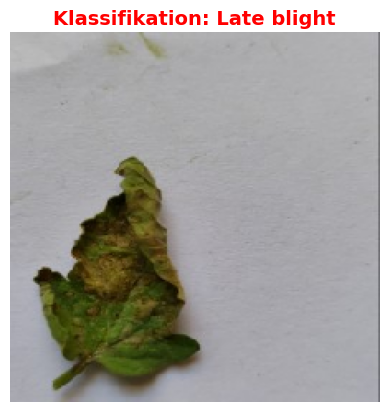

Scores pro Krankheit:
Early blight             : 0.196
Late blight              : 0.444
Leaf Miner               : 0.098
Magnesium Deficiency     : 0.192
Nitrogen Deficiency      : 0.018
Pottassium Deficiency    : 0.001
Spotted Wilt Virus       : 0.069

Thresholds pro Label (effektiv genutzt):
Early blight             : 0.50
Late blight              : 0.10
Leaf Miner               : 0.30
Magnesium Deficiency     : 0.45
Nitrogen Deficiency      : 0.40
Pottassium Deficiency    : 0.50
Spotted Wilt Virus       : 0.25

Aktive Labels (nach Logik): Late blight


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow import keras

# ---------------------------------------------------
# Modell laden (nur für Inferenz, deshalb compile=False)
# -> falls du das neue AdamW/weighted-Modell trainiert hast:
#MODEL_PATH = "plant_cnn_from_scratch_multilabel_dataset2_weighted_adamw.keras"
# falls du beim alten Namen geblieben bist:
MODEL_PATH = "plant_cnn_from_scratch_multilabel_dataset2.keras"

plant_cnn = keras.models.load_model(
    MODEL_PATH,
    compile=False   # wir kompilieren zum Vorhersagen nicht neu
)

# Bildgröße wie beim Training
# (falls schon global definiert, kannst du das hier auch weglassen)
IMG_SIZE = (224, 224)

# Reihenfolge der Krankheiten (muss zur Output-Reihenfolge im Modell passen)
# (falls schon global definiert, kannst du das hier auch weglassen)
DISEASE_COLS = [
    "Early blight",
    "Late blight",
    "Leaf Miner",
    "Magnesium Deficiency",
    "Nitrogen Deficiency",
    "Pottassium Deficiency",
    "Spotted Wilt Virus",
]

# ---------------------------------------------------
# WICHTIG:
# - BEST_THR wurde vorher berechnet (best_thresholds_per_label)
# - THR_EFFECTIVE wurde aus BEST_THR + thr_manual gebaut
#   -> wir benutzen THR_EFFECTIVE als Standard-Thresholds
# ---------------------------------------------------

def predict_image_plant_cnn(
    img_path,
    model=None,
    thresholds=None,   # per-Label-Thresholds; None => THR_EFFECTIVE
    min_labels=1,      # mindestens so viele Labels anzeigen, falls keine über Threshold
    top_k=None         # falls gesetzt: max. top_k Labels (nach Score)
):
    if model is None:
        model = plant_cnn

    # Welche Thresholds verwenden?
    if thresholds is None:
        thr_used = np.array(THR_EFFECTIVE, dtype="float32")
    else:
        thr_used = np.array(thresholds, dtype="float32")

    # --- Bild laden ---
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    x = np.expand_dims(img_array, axis=0)  # kein /255 – Rescaling ist im Modell

    # --- Vorhersage ---
    probs = model.predict(x)[0]  # Vektor (NUM_LABELS,)

    # 1) Labels über ihrem individuellen Threshold
    active_idx = np.where(probs >= thr_used)[0]

    # 2) Falls gar nichts über Threshold -> mind. min_labels mit höchstem Score
    if active_idx.size == 0 and min_labels is not None and min_labels > 0:
        active_idx = np.argsort(probs)[-min_labels:]

    # 3) Falls sehr viele aktiv -> auf top_k mit höchstem Score begrenzen
    if top_k is not None and active_idx.size > top_k:
        # Sortiere nach Scores innerhalb der aktiven Indizes und nimm die besten k
        local_sorted = np.argsort(probs[active_idx])[-top_k:]
        active_idx = active_idx[local_sorted]

    # final aktive Labels
    active_labels = [DISEASE_COLS[i] for i in active_idx]

    if not active_labels:
        label_str = "keine Krankheit erkannt"
        color = "green"
    else:
        label_str = ", ".join(active_labels)
        color = "red"

    # --- Anzeige ---
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Klassifikation: {label_str}", color=color, fontsize=14, weight="bold")
    plt.show()

    # --- Detailausgabe ---
    print("Scores pro Krankheit:")
    for name, p in zip(DISEASE_COLS, probs):
        print(f"{name:25s}: {p:.3f}")

    print("\nThresholds pro Label (effektiv genutzt):")
    for name, t in zip(DISEASE_COLS, thr_used):
        print(f"{name:25s}: {t:.2f}")

    print(f"\nAktive Labels (nach Logik): {label_str}")


# Beispielaufruf
predict_image_plant_cnn(
    "/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2/test/IMG20220323102223.jpg",
    top_k=3   # kannst du variieren (z.B. 2–3)
)


**Train Test Val split als Grafik darstellen**
**Visualizierung von Rohdaten (vor dem Preprocessing-Schritt)**
**Visualizierung von bereits vorverarbeitenden Daten (sprich nach dem Preprocessing-Schritt)**
**Visualizierung der Loss- und Accuracy-Kurven**

**Liste der Herangehenweise:**
***Wie haben wir die Hyperparamter so gewählt?***
- Batch-Size
- Epochen
- usw.

***Weshalb haben wir uns für die entsprechenden Vorverarbeitungsschritten entschieden?***


***Weshalb haben wir die entsprechenden Metriken und Funktionen ausgewählt? (Im Kontext des verwendeten Datensatz erklären!!)***
- Verlustfunktion (aktuell verwenden wir: binary_crossentropy)
- Optimirungfunktion (aktuell verwenden wir: Adam-Optimizer vllt. AdamW-Optimizer)
- Bewertungsmetriken (aktuell verwenden wir: BinaryAccuracy und AUC)
- Learningrate (aktuell verwenden wir: 1e-4)


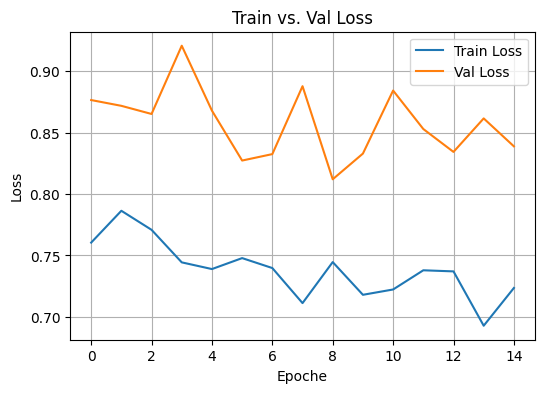

In [14]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.title("Train vs. Val Loss")
plt.legend()
plt.grid(True)
plt.show()
